# Fixed Qubit Trade Optimizer Notebook

This notebook gives you a **patched Qiskit notebook file** for qubit-based trade basket optimization.

It is designed to avoid the `TypeError: Invalid circuits, expected Sequence[QuantumCircuit]` issue by:
- using `qiskit-optimization >= 0.7.0`
- using the modern `StatevectorSampler`
- importing `QAOA` and `COBYLA` from `qiskit_optimization`

Pipeline:
1. install compatible packages
2. create candidate trades
3. build a quadratic portfolio optimization problem
4. convert it to QUBO
5. convert QUBO to an Ising operator
6. run QAOA with a qubit-backed solver
7. compare against a classical brute-force result


In [1]:
!pip install -q --upgrade "qiskit>=1.1" "qiskit-optimization>=0.7.0" "qiskit-aer>=0.15.0"

In [2]:
# Run this first in Colab, then restart the runtime.
!pip install -q --upgrade \
  "qiskit>=1.1" \
  "qiskit-optimization>=0.7.0" \
  "qiskit-aer>=0.15.0" \
  "pandas" \
  "numpy" \
  "matplotlib"


## Imports


In [2]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from qiskit.primitives import StatevectorSampler
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.converters import QuadraticProgramToQubo
from qiskit_optimization.algorithms import MinimumEigenOptimizer
from qiskit_optimization.minimum_eigensolvers import QAOA
from qiskit_optimization.optimizers import COBYLA

np.random.seed(42)


## Example candidate trades


In [3]:
trade_df = pd.DataFrame([
    {"trade": "A", "question": "Election market 1", "edge": 0.030, "size_dollars": 18, "risk_score": 0.20, "corr_group": "politics"},
    {"trade": "B", "question": "Election market 2", "edge": 0.026, "size_dollars": 16, "risk_score": 0.16, "corr_group": "politics"},
    {"trade": "C", "question": "Sports market 1",   "edge": 0.040, "size_dollars": 25, "risk_score": 0.30, "corr_group": "sports"},
    {"trade": "D", "question": "Sports market 2",   "edge": 0.021, "size_dollars": 14, "risk_score": 0.14, "corr_group": "sports"},
    {"trade": "E", "question": "Crypto market 1",   "edge": 0.034, "size_dollars": 20, "risk_score": 0.22, "corr_group": "crypto"},
    {"trade": "F", "question": "Crypto market 2",   "edge": 0.028, "size_dollars": 17, "risk_score": 0.18, "corr_group": "crypto"},
])

BANKROLL = 60
MAX_POSITIONS = 3
RISK_LAMBDA = 0.08
CORR_LAMBDA = 0.05
PENALTY = 8.0

display(trade_df)
print("BANKROLL =", BANKROLL)
print("MAX_POSITIONS =", MAX_POSITIONS)


,trade,question,edge,size_dollars,risk_score,corr_group
0,A,Election market 1,0.030,18,0.20,politics
1,B,Election market 2,0.026,16,0.16,politics
2,C,Sports market 1,0.040,25,0.30,sports
3,D,Sports market 2,0.021,14,0.14,sports
4,E,Crypto market 1,0.034,20,0.22,crypto
5,F,Crypto market 2,0.028,17,0.18,crypto


BANKROLL = 60
MAX_POSITIONS = 3


## Build edge vector and correlation matrix


In [4]:
n = len(trade_df)
edges = trade_df["edge"].to_numpy(dtype=float)
sizes = trade_df["size_dollars"].to_numpy(dtype=float)
risks = trade_df["risk_score"].to_numpy(dtype=float)

corr = np.zeros((n, n), dtype=float)
for i in range(n):
    for j in range(n):
        if i == j:
            corr[i, j] = 0.0
        elif trade_df.loc[i, "corr_group"] == trade_df.loc[j, "corr_group"]:
            corr[i, j] = 0.8
        else:
            corr[i, j] = 0.15

corr_df = pd.DataFrame(corr, index=trade_df["trade"], columns=trade_df["trade"])
display(corr_df)


trade,A,B,C,D,E,F
trade,,,,,,
A,0.00,0.80,0.15,0.15,0.15,0.15
B,0.80,0.00,0.15,0.15,0.15,0.15
C,0.15,0.15,0.00,0.80,0.15,0.15
D,0.15,0.15,0.80,0.00,0.15,0.15
E,0.15,0.15,0.15,0.15,0.00,0.80
F,0.15,0.15,0.15,0.15,0.80,0.00


## Classical brute-force check


In [5]:
def portfolio_value(mask, edges, sizes, risks, corr, bankroll, max_positions, risk_lambda, corr_lambda):
    mask = np.array(mask, dtype=int)
    total_size = np.sum(mask * sizes)
    total_positions = np.sum(mask)

    if total_size > bankroll or total_positions > max_positions:
        return -1e9

    reward = np.sum(mask * edges)
    risk_penalty = risk_lambda * np.sum(mask * risks)

    corr_penalty = 0.0
    for i in range(len(mask)):
        for j in range(i + 1, len(mask)):
            corr_penalty += mask[i] * mask[j] * corr[i, j]
    corr_penalty *= corr_lambda

    return float(reward - risk_penalty - corr_penalty)

best_value = -1e9
best_mask = None
for mask in itertools.product([0, 1], repeat=n):
    val = portfolio_value(mask, edges, sizes, risks, corr, BANKROLL, MAX_POSITIONS, RISK_LAMBDA, CORR_LAMBDA)
    if val > best_value:
        best_value = val
        best_mask = np.array(mask)

print("Classical best mask:", best_mask)
print("Classical best value:", round(best_value, 6))
display(trade_df[best_mask == 1].copy())


Classical best mask: [0 0 1 0 1 0]
Classical best value: 0.0249


,trade,question,edge,size_dollars,risk_score,corr_group
2,C,Sports market 1,0.040,25,0.30,sports
4,E,Crypto market 1,0.034,20,0.22,crypto


## Build the Quadratic Program


In [6]:
qp = QuadraticProgram("trade_basket_qubits")

for i in range(n):
    qp.binary_var(name=f"x{i}")

linear = {f"x{i}": float(edges[i] - RISK_LAMBDA * risks[i]) for i in range(n)}

quadratic = {}
for i in range(n):
    for j in range(i + 1, n):
        quadratic[(f"x{i}", f"x{j}")] = float(-CORR_LAMBDA * corr[i, j])

qp.maximize(linear=linear, quadratic=quadratic)

qp.linear_constraint(
    linear={f"x{i}": float(sizes[i]) for i in range(n)},
    sense="<=",
    rhs=float(BANKROLL),
    name="budget"
)

qp.linear_constraint(
    linear={f"x{i}": 1.0 for i in range(n)},
    sense="<=",
    rhs=float(MAX_POSITIONS),
    name="max_positions"
)

print(qp.prettyprint())


Problem name: trade_basket_qubits

Maximize
  -0.04000000000000001*x0*x1 - 0.0075*x0*x2 - 0.0075*x0*x3 - 0.0075*x0*x4
  - 0.0075*x0*x5 - 0.0075*x1*x2 - 0.0075*x1*x3 - 0.0075*x1*x4 - 0.0075*x1*x5
  - 0.04000000000000001*x2*x3 - 0.0075*x2*x4 - 0.0075*x2*x5 - 0.0075*x3*x4
  - 0.0075*x3*x5 - 0.04000000000000001*x4*x5 + 0.013999999999999999*x0
  + 0.013199999999999998*x1 + 0.016*x2 + 0.0098*x3 + 0.0164*x4
  + 0.013600000000000001*x5

Subject to
  Linear constraints (2)
    18*x0 + 16*x1 + 25*x2 + 14*x3 + 20*x4 + 17*x5 <= 60  'budget'
    x0 + x1 + x2 + x3 + x4 + x5 <= 3  'max_positions'

  Binary variables (6)
    x0 x1 x2 x3 x4 x5



## Convert to QUBO


In [7]:
converter = QuadraticProgramToQubo(penalty=PENALTY)
qubo = converter.convert(qp)

print("\nQUBO formulation:\n")
print(qubo.prettyprint())



QUBO formulation:

Problem name: trade_basket_qubits

Minimize
  8*budget@int_slack@0^2 + 32*budget@int_slack@0*budget@int_slack@1
  + 64*budget@int_slack@0*budget@int_slack@2
  + 128*budget@int_slack@0*budget@int_slack@3
  + 256*budget@int_slack@0*budget@int_slack@4
  + 464*budget@int_slack@0*budget@int_slack@5 + 32*budget@int_slack@1^2
  + 128*budget@int_slack@1*budget@int_slack@2
  + 256*budget@int_slack@1*budget@int_slack@3
  + 512*budget@int_slack@1*budget@int_slack@4
  + 928*budget@int_slack@1*budget@int_slack@5 + 128*budget@int_slack@2^2
  + 512*budget@int_slack@2*budget@int_slack@3
  + 1024*budget@int_slack@2*budget@int_slack@4
  + 1856*budget@int_slack@2*budget@int_slack@5 + 512*budget@int_slack@3^2
  + 2048*budget@int_slack@3*budget@int_slack@4
  + 3712*budget@int_slack@3*budget@int_slack@5 + 2048*budget@int_slack@4^2
  + 7424*budget@int_slack@4*budget@int_slack@5 + 6728*budget@int_slack@5^2
  + 8*max_positions@int_slack@0^2
  + 32*max_positions@int_slack@0*max_positions@int

## Convert to Ising / qubit operator


In [8]:
ising_op, offset = qubo.to_ising()
print("Number of qubits:", ising_op.num_qubits)
print("Offset:", offset)
print("\nIsing operator:")
print(ising_op)


Number of qubits: 14
Offset: 11584.011000000015

Ising operator:
SparsePauliOp(['IIIIIIIIIIIIIZ', 'IIIIIIIIIIIIZI', 'IIIIIIIIIIIZII', 'IIIIIIIIIIZIII', 'IIIIIIIIIZIIII', 'IIIIIIIIZIIIII', 'IIIIIIIZIIIIII', 'IIIIIIZIIIIIII', 'IIIIIZIIIIIIII', 'IIIIZIIIIIIIII', 'IIIZIIIIIIIIII', 'IIZIIIIIIIIIII', 'IZIIIIIIIIIIII', 'ZIIIIIIIIIIIII', 'IIIIIIIIIIIIZZ', 'IIIIIIIIIIIZIZ', 'IIIIIIIIIIZIIZ', 'IIIIIIIIIZIIIZ', 'IIIIIIIIZIIIIZ', 'IIIIIIIZIIIIIZ', 'IIIIIIZIIIIIIZ', 'IIIIIZIIIIIIIZ', 'IIIIZIIIIIIIIZ', 'IIIZIIIIIIIIIZ', 'IIZIIIIIIIIIIZ', 'IZIIIIIIIIIIIZ', 'ZIIIIIIIIIIIIZ', 'IIIIIIIIIIIZZI', 'IIIIIIIIIIZIZI', 'IIIIIIIIIZIIZI', 'IIIIIIIIZIIIZI', 'IIIIIIIZIIIIZI', 'IIIIIIZIIIIIZI', 'IIIIIZIIIIIIZI', 'IIIIZIIIIIIIZI', 'IIIZIIIIIIIIZI', 'IIZIIIIIIIIIZI', 'IZIIIIIIIIIIZI', 'ZIIIIIIIIIIIZI', 'IIIIIIIIIIZZII', 'IIIIIIIIIZIZII', 'IIIIIIIIZIIZII', 'IIIIIIIZIIIZII', 'IIIIIIZIIIIZII', 'IIIIIZIIIIIZII', 'IIIIZIIIIIIZII', 'IIIZIIIIIIIZII', 'IIZIIIIIIIIZII', 'IZIIIIIIIIIZII', 'ZIIIIIIIIIIZII', 'IIIIIIIIIZZIII', 'I

## Qubit mapping


In [9]:
qubit_map = pd.DataFrame({
    "qubit_index": list(range(n)),
    "trade": trade_df["trade"],
    "question": trade_df["question"],
    "edge": trade_df["edge"],
    "size_dollars": trade_df["size_dollars"],
    "risk_score": trade_df["risk_score"],
})
display(qubit_map)


,qubit_index,trade,question,edge,size_dollars,risk_score
0,0,A,Election market 1,0.030,18,0.20
1,1,B,Election market 2,0.026,16,0.16
2,2,C,Sports market 1,0.040,25,0.30
3,3,D,Sports market 2,0.021,14,0.14
4,4,E,Crypto market 1,0.034,20,0.22
5,5,F,Crypto market 2,0.028,17,0.18


## QAOA solve


In [10]:
sampler = StatevectorSampler(seed=123)

qaoa_mes = QAOA(
    sampler=sampler,
    optimizer=COBYLA(maxiter=100),
    reps=2,
)

qaoa = MinimumEigenOptimizer(qaoa_mes)
qaoa_result = qaoa.solve(qubo)

print("QAOA status:", qaoa_result.status)
print("QAOA objective value:", qaoa_result.fval)
print("QAOA variable assignment:", qaoa_result.x)

# Map variable names to returned values
solution_map = dict(zip([v.name for v in qubo.variables], qaoa_result.x))

# Extract only the original decision variables x0...x{n-1}
qaoa_mask = np.array([int(round(solution_map[f"x{i}"])) for i in range(n)], dtype=int)

print("Trade-only mask:", qaoa_mask)
print("Mask length:", len(qaoa_mask))
print("Number of trades:", len(trade_df))

qaoa_selected = trade_df.loc[qaoa_mask == 1].copy()
qaoa_selected["chosen_by"] = "QAOA"
display(qaoa_selected)

QAOA status: OptimizationResultStatus.SUCCESS
QAOA objective value: -0.015500000001338776
QAOA variable assignment: [0. 1. 0. 1. 0. 0. 0. 1. 1. 1. 1. 0. 1. 0.]
Trade-only mask: [0 1 0 1 0 0]
Mask length: 6
Number of trades: 6


,trade,question,edge,size_dollars,risk_score,corr_group,chosen_by
1,B,Election market 2,0.026,16,0.16,politics,QAOA
3,D,Sports market 2,0.021,14,0.14,sports,QAOA


## Compare QAOA vs classical


In [11]:
print("Classical best mask:", best_mask)
print("QAOA mask:", qaoa_mask)
print("Same selection?", np.array_equal(best_mask, qaoa_mask))


Classical best mask: [0 0 1 0 1 0]
QAOA mask: [0 1 0 1 0 0]
Same selection? False


## Simple plots


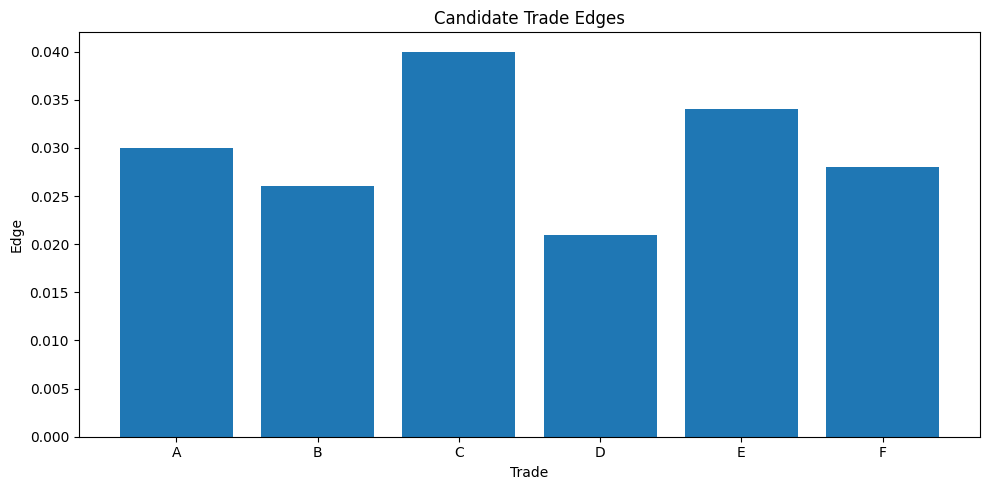

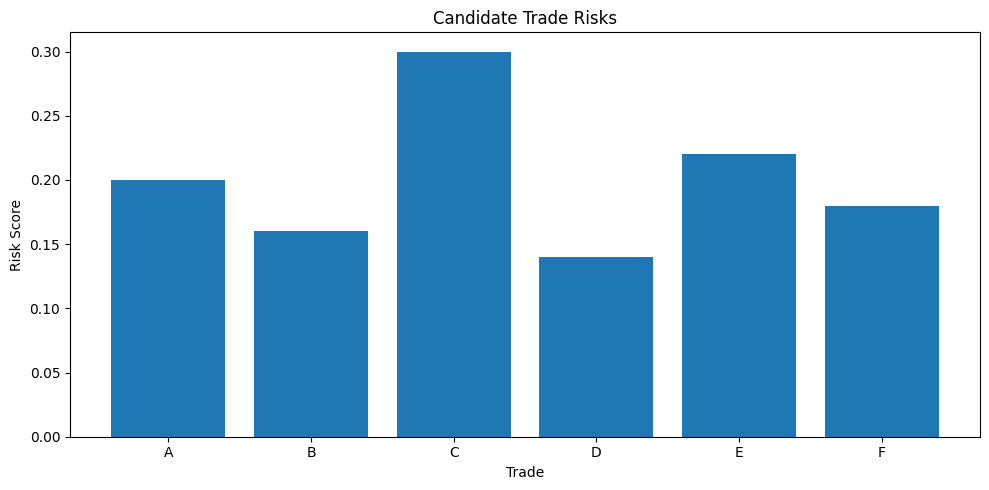

In [12]:
plt.figure(figsize=(10, 5))
plt.bar(trade_df["trade"], trade_df["edge"])
plt.xlabel("Trade")
plt.ylabel("Edge")
plt.title("Candidate Trade Edges")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(trade_df["trade"], trade_df["risk_score"])
plt.xlabel("Trade")
plt.ylabel("Risk Score")
plt.title("Candidate Trade Risks")
plt.tight_layout()
plt.show()
